<a href="https://colab.research.google.com/github/hamzayawa/pytorch-learning/blob/main/04_news_topic_classifier/04_huggingface_news_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


torch.manual_seed(42)
torch.set_num_threads(2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
print("Pytorch Version: ", torch.__version__)
print("Cuda Version: ", torch.version.cuda)

cuda
Pytorch Version:  2.11.0+cu130
Cuda Version:  13.0


In [1]:
!pip install -q torch datasets pandas matplotlib scikit-learn gradio

In [5]:
dataset = load_dataset("fancyzhx/ag_news")

dataset

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

In [6]:
print(dataset['train'])
print(dataset['test'])

Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})


In [20]:
print(dataset["train"].column_names)

['text', 'label']


In [8]:
print(dataset['train'].features)
print(dataset['test'].features)

{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}
{'text': Value('string'), 'label': ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])}


In [9]:
print(dataset['train'][0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [10]:
for i in range(5):
    example = dataset["train"][i]

    print("Example", i)
    print("Text:", example["text"])
    print("Label:", example["label"])
    print("-" * 80)

Example 0
Text: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 2
--------------------------------------------------------------------------------
Example 1
Text: Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Label: 2
--------------------------------------------------------------------------------
Example 2
Text: Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Label: 2
--------------------------------------------------------------------------------
Example 3
Text: Iraq Halts Oil Export

In [11]:
label_names = ["World", "Sports", "Business", "Sci/Tech"]

for i, name in enumerate(label_names):
    print(i, "→", name)

0 → World
1 → Sports
2 → Business
3 → Sci/Tech


In [12]:
example = dataset["train"][0]

print("Text:")
print(example["text"])

print()
print("Numeric label:", example["label"])
print("Class:", label_names[example["label"]])

Text:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Numeric label: 2
Class: Business


In [13]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


In [15]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    120000 non-null  object
 1   label   120000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.8+ MB


In [16]:
print("Training examples:", len(train_df))
print("Testing examples:", len(test_df))

Training examples: 120000
Testing examples: 7600


In [21]:
class_counts = train_df["label"].value_counts().sort_index()

print(class_counts)

label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


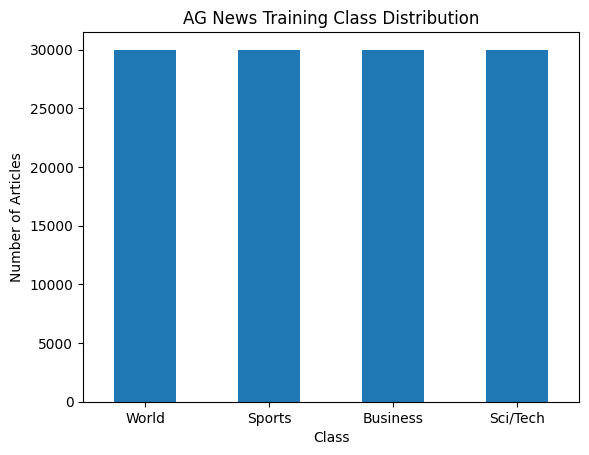

In [22]:
class_counts.plot(
    kind="bar",
    xlabel="Class",
    ylabel="Number of Articles",
    title="AG News Training Class Distribution"
)

plt.xticks(
    range(len(label_names)),
    label_names,
    rotation=0
)

plt.show()

In [23]:
train_df["text_length"] = train_df["text"].str.split().str.len()

train_df["text_length"].describe()

,text_length
count,120000.000000
mean,37.847450
std,10.085245
min,8.000000
25%,32.000000
50%,37.000000
75%,43.000000
max,177.000000


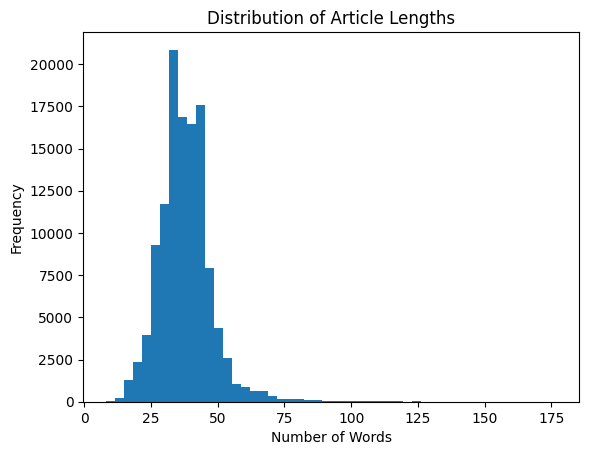

In [24]:
train_df["text_length"].plot(
    kind="hist",
    bins=50,
    title="Distribution of Article Lengths",
    xlabel="Number of Words"
)

plt.show()

In [25]:
print("Shortest article:",
      train_df["text_length"].min())

print("Longest article:",
      train_df["text_length"].max())

print("Average article:",
      train_df["text_length"].mean())

Shortest article: 8
Longest article: 177
Average article: 37.84745
